In [1]:
import numpy as np
from numpy import pi as π
from tqdm.notebook import tqdm, trange
import matplotlib.pyplot as plt
import firedrake
from firedrake import Constant, inner, grad, div, dx as dζ, ds, dS
import irksome
from irksome import Dt

In [2]:
nz = 16
mesh = firedrake.UnitIntervalMesh(nz)

In [3]:
family = "CG"  # <- revise later
degree = 1
density_element = firedrake.FiniteElement(family, "interval", degree)
Q = firedrake.FunctionSpace(mesh, density_element)

thickness_element = firedrake.FiniteElement("R", "interval", 0)
R = firedrake.FunctionSpace(mesh, thickness_element)

In [4]:
h = firedrake.Function(R)
h.assign(10.0)
q = firedrake.TestFunction(R)

t = Constant(0.0)

a_0 = Constant(0.5)
δa = Constant(0.125)
a = a_0 + δa * firedrake.cos(2 * π * t)
m = -a_0

F_h = (Dt(h) - a + m) * q * dζ

In [5]:
method = irksome.BackwardEuler()
timestep = 1/24
dt = Constant(timestep)
solver = irksome.TimeStepper(F_h, method, t, dt, h)

In [6]:
final_time = 5.0
num_steps = int(final_time / timestep)
hs = [h.copy(deepcopy=True)]
for step in trange(num_steps):
    solver.advance()
    t.assign(t + dt)
    hs.append(h.copy(deepcopy=True))

  0%|          | 0/120 [00:00<?, ?it/s]

In [7]:
Hs = np.array([float(h) for h in hs])

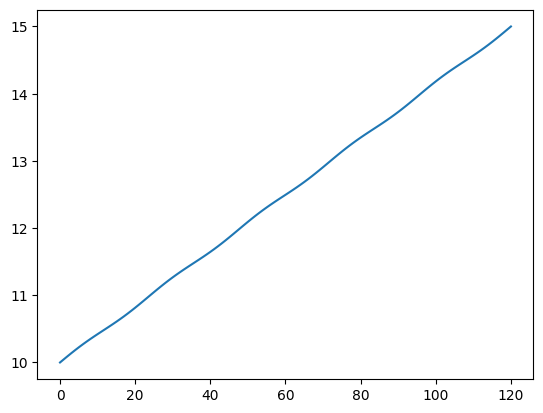

In [8]:
fig, ax = plt.subplots()
ax.plot(Hs);